<a href="https://colab.research.google.com/github/Yahsakem1/ml_projects/blob/main/e_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

In [3]:
customers = pd.read_csv("/content/olist_customers_dataset.csv")
geolocation = pd.read_csv("/content/olist_geolocation_dataset.csv")
order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
orders = pd.read_csv("/content/olist_orders_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
sellers = pd.read_csv("/content/olist_sellers_dataset.csv")
category_name = pd.read_csv("/content/product_category_name_translation.csv")


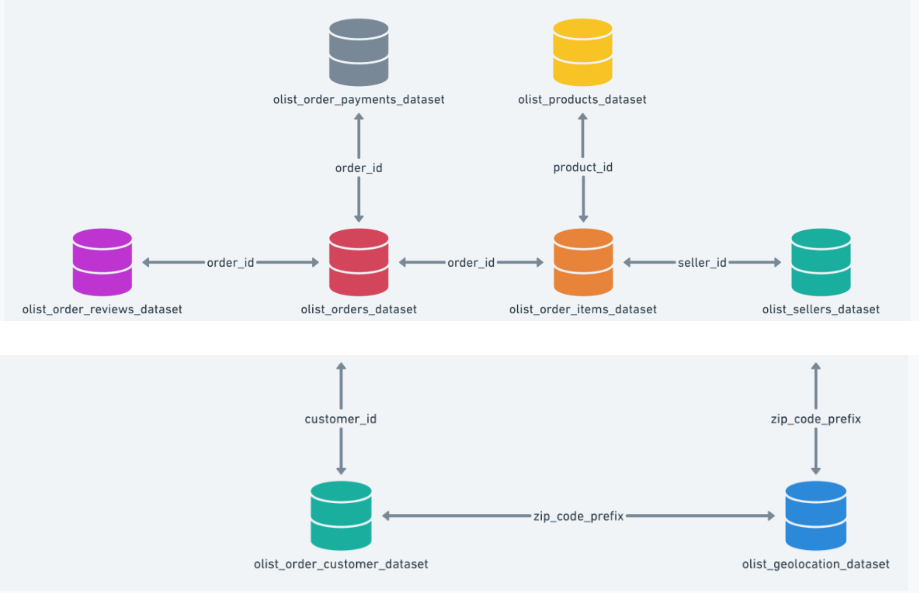

#Проанализируем товары

Самые прибыльные товары

In [4]:
products_price = pd.merge(order_items,products[["product_id","product_category_name"]],how = "left",on = "product_id")
product_agg = products_price.groupby("product_category_name").agg(
    count_sell_product = ("product_category_name","count"),
    mean_sell_product = ("price","mean"),
    min_sell_product = ("price","min"),
    max_sell_product = ("price","max"),
    sum_sell_product = ("price","sum")
)
product_agg.sort_values(by = "sum_sell_product",ascending=False)

,count_sell_product,mean_sell_product,min_sell_product,max_sell_product,sum_sell_product
product_category_name,,,,,
beleza_saude,9670,130.163531,1.20,3124.00,1258681.34
relogios_presentes,5991,201.135984,8.99,3999.90,1205005.68
cama_mesa_banho,11115,93.296327,6.99,1999.98,1036988.68
esporte_lazer,8641,114.344285,4.50,4059.00,988048.97
informatica_acessorios,7827,116.513903,3.90,3699.99,911954.32
...,...,...,...,...,...
flores,33,33.637576,15.60,65.90,1110.04
casa_conforto_2,30,25.342333,12.90,219.99,760.27
cds_dvds_musicais,14,52.142857,45.00,65.00,730.00


Самые продаваемые

In [5]:
product_agg.sort_values(by = "count_sell_product",ascending=False).head(5)

,count_sell_product,mean_sell_product,min_sell_product,max_sell_product,sum_sell_product
product_category_name,,,,,
cama_mesa_banho,11115,93.296327,6.99,1999.98,1036988.68
beleza_saude,9670,130.163531,1.20,3124.00,1258681.34
esporte_lazer,8641,114.344285,4.50,4059.00,988048.97
moveis_decoracao,8334,87.564494,4.90,1899.00,729762.49
informatica_acessorios,7827,116.513903,3.90,3699.99,911954.32


Самые дорогие в среднем по продажам

In [6]:
product_agg.sort_values(by = "mean_sell_product",ascending=False).head(5)

,count_sell_product,mean_sell_product,min_sell_product,max_sell_product,sum_sell_product
product_category_name,,,,,
pcs,203,1098.340542,34.50,6729.00,222963.13
portateis_casa_forno_e_cafe,76,624.285658,10.19,2899.00,47445.71
eletrodomesticos_2,238,476.124958,13.90,2350.00,113317.74
agro_industria_e_comercio,212,342.124858,12.99,2990.00,72530.47
instrumentos_musicais,680,281.616000,4.90,4399.87,191498.88


Посмотрим лучших продавцов

In [7]:
product_agg_seller = order_items.groupby("seller_id").agg(
    count_sell_product = ("seller_id","count"),
    mean_sell_product = ("price","mean"),
    min_sell_product = ("price","min"),
    max_sell_product = ("price","max"),
    sum_sell_product = ("price","sum")
).reset_index()
products_seller = pd.merge(product_agg_seller,sellers,how = "left",on = "seller_id")
products_seller.sort_values(by = "sum_sell_product",ascending=False).head(5)

,seller_id,count_sell_product,mean_sell_product,min_sell_product,max_sell_product,sum_sell_product,seller_zip_code_prefix,seller_city,seller_state
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,198.505735,54.90,899.99,229472.63,14840,guariba,SP
1013,53243585a1d6dc2643021fd1853d8905,410,543.356220,170.00,1649.99,222776.05,42738,lauro de freitas,BA
881,4a3ca9315b744ce9f8e9374361493884,1987,100.892260,12.90,884.00,200472.92,14940,ibitinga,SP
3024,fa1c13f2614d7b5c4749cbc52fecda94,586,331.129744,84.90,3999.90,194042.03,13170,sumare,SP
1535,7c67e1448b00f6e969d365cea6b010ab,1364,137.774113,29.99,401.34,187923.89,8577,itaquaquecetuba,SP


#Статистика по городам

Посмотрим также статистику по городам и по штатам

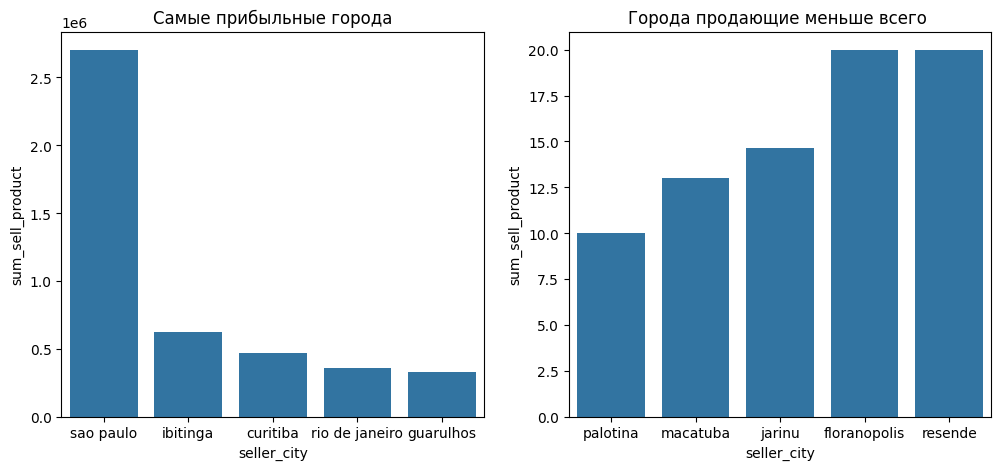

In [8]:
seller_city = products_seller.groupby("seller_city")["sum_sell_product"].sum().reset_index()
top_seller_city = seller_city.nlargest(5,"sum_sell_product")
bottom_seller_city = seller_city.nsmallest(5,"sum_sell_product")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.barplot(x = top_seller_city["seller_city"],y = top_seller_city["sum_sell_product"],ax = axes[0])
axes[0].set_title("Самые прибыльные города")
sns.barplot(x = bottom_seller_city["seller_city"],y = bottom_seller_city["sum_sell_product"],ax = axes[1])
axes[1].set_title("Города продающие меньше всего ")
plt.show()

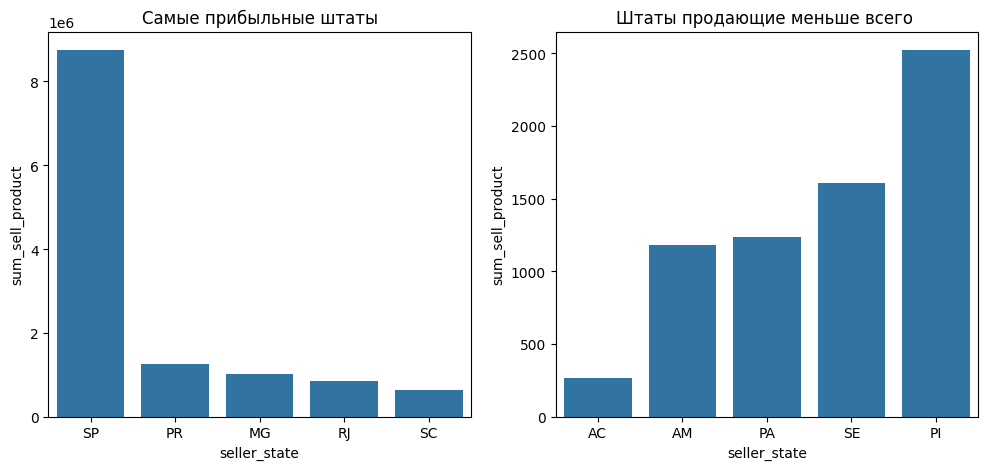

In [9]:
seller_state = products_seller.groupby("seller_state")["sum_sell_product"].sum().reset_index()
top_seller_state = seller_state.nlargest(5,"sum_sell_product")
bottom_seller_state = seller_state.nsmallest(5,"sum_sell_product")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.barplot(x = top_seller_state["seller_state"],y = top_seller_state["sum_sell_product"],ax = axes[0])
axes[0].set_title("Самые прибыльные штаты")
sns.barplot(x = bottom_seller_state["seller_state"],y = bottom_seller_state["sum_sell_product"],ax = axes[1])
axes[1].set_title("Штаты продающие меньше всего ")
plt.show()

In [10]:
geo_agg = geolocation.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat", "median"),
    lng=("geolocation_lng", "median")
).reset_index()
order_revenue = order_items.groupby("order_id")["price"].sum().reset_index()
orders_customers = orders.merge(
    customers[["customer_id", "customer_zip_code_prefix", "customer_city", "customer_state"]],
    on="customer_id", how="left"
)
sales_by_customer = orders_customers.merge(order_revenue, on="order_id", how="left")
sales_by_zip = sales_by_customer.groupby("customer_zip_code_prefix").agg(
    total_sales=("price", "sum"),
    orders_count=("order_id", "nunique")
).reset_index()
sales_map_data = sales_by_zip.merge(
    geo_agg, left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix", how="left"
).dropna(subset=["lat", "lng"])
fig = px.scatter_mapbox(
    sales_map_data,
    lat="lat", lon="lng",
    size="total_sales",
    color="total_sales",
    hover_data={"orders_count": True, "total_sales": ":.2f"},
    color_continuous_scale="Viridis",
    size_max=25,
    zoom=3,
    mapbox_style="carto-positron",  # токен Mapbox не нужен
    title="Продажи по регионам (customer zip)"
)
fig.show()

#Рейтинг продавцов

Посмотрим на рейтингы продавцов и товаров

In [11]:
reviews_order_price = pd.merge(products_price,order_reviews[["review_score","order_id"]], how = "inner",on = "order_id")
reviews_order_price_seller = pd.merge(reviews_order_price,sellers,how = "inner", on = "seller_id")
reviews_order_price_seller.groupby("seller_id").agg(mean_score = ("review_score","mean"), count_score = ("review_score","count"),sum_sell_product = ("price","sum")).query("count_score > 1").sort_values(by = ["mean_score","count_score"],ascending = False).head(5)

,mean_score,count_score,sum_sell_product
seller_id,,,
48efc9d94a9834137efd9ea76b065a38,5.0,34,345.6
a08692680c77d30a0b4280da5df01c5a,5.0,17,2433.0
0b36063d5818f81ccb94b54adfaebbf5,5.0,15,765.0
c8c1bea22194a4eefa2dc9a9fa89f536,5.0,13,1266.0
2addf05f476d0637864454e93ba673d5,5.0,12,4552.0


Это продавцы с лучшей оценкой и с приемлимым количеством оценок

Также посмотрим на лучших продавцов с большим количеством оценок

In [12]:
reviews_order_price_seller.groupby("seller_id").agg(mean_score = ("review_score","mean"), count_score = ("review_score","count"),sum_sell_product = ("price","sum")).query("count_score > 1000").sort_values(by = ["mean_score","count_score"],ascending = False).head(5)

,mean_score,count_score,sum_sell_product
seller_id,,,
7a67c85e85bb2ce8582c35f2203ad736,4.234991,1166,141130.58
4869f7a5dfa277a7dca6462dcf3b52b2,4.122822,1148,228071.04
3d871de0142ce09b7081e2b9d1733cb1,4.114437,1136,93960.80
da8622b14eb17ae2831f4ac5b9dab84a,4.071429,1568,161993.97
cc419e0650a3c5ba77189a1882b7556a,4.069575,1811,106059.06


Худшие продавцы

In [13]:
reviews_order_price_seller.groupby("seller_id").agg(mean_score = ("review_score","mean"), count_score = ("review_score","count"),sum_sell_product = ("price","sum")).sort_values(by = ["mean_score","count_score"],ascending = [True,False]).head(5)

,mean_score,count_score,sum_sell_product
seller_id,,,
8d92f3ea807b89465643c219455e7369,1.0,8,121.20
a0e19590a0923cdd0614ea9427713ced,1.0,7,258.30
010da0602d7774602cd1b3f5fb7b709e,1.0,5,849.50
3bfad056cf05c00dabe2f895925d83b1,1.0,5,206.65
90d4125885ab6c86e8820a722be71974,1.0,5,1299.55


#Время доставки

Так попробуем проверить гипотезу, что оценка зависит от времени доставки или как то коррелирует с ней

In [14]:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="ignore")
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"], errors="ignore")
orders["Time_delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_delivered_carrier_date"])/ np.timedelta64(1, "D")
orders_delivery = pd.merge(orders,order_items[["order_id","seller_id"]], how = "inner",on = "order_id")
a = reviews_order_price_seller.groupby("seller_id").agg(mean_score = ("review_score","mean")).reset_index()
b = orders_delivery.groupby("seller_id")["Time_delivery_days"].mean().dropna().reset_index()
delivery_sellers = pd.merge(a,b,how = "right", on = "seller_id")

/tmp/ipykernel_509/4208596035.py:1: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead

/tmp/ipykernel_509/4208596035.py:2: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



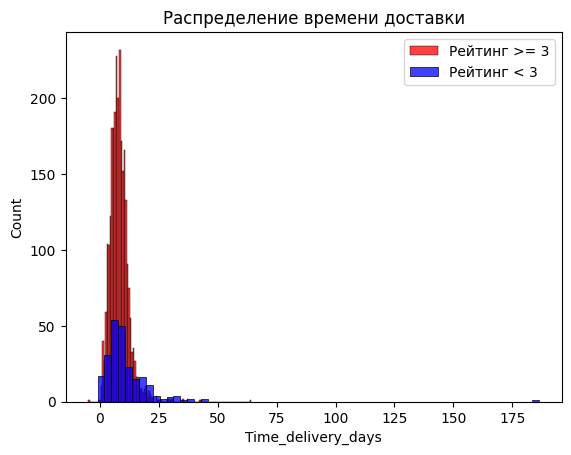

In [15]:
sns.histplot(data = delivery_sellers[delivery_sellers["mean_score"] >= 3], x = "Time_delivery_days",color = "red", label = "Рейтинг >= 3")
sns.histplot(data = delivery_sellers[delivery_sellers["mean_score"] < 3], x = "Time_delivery_days",color = "blue", label = "Рейтинг < 3")
plt.title("Распределение времени доставки")
plt.legend()
plt.show()

Видно скошенное распределение и так же выборки отличаются по количеству наблюдений

Для теста используем тест Манна-Уитни

H0 = разницы нет

H1 = разница есть

a = 0.05

B = 0.2

In [16]:
group_high = delivery_sellers[delivery_sellers["mean_score"] >= 3]["Time_delivery_days"].dropna()
group_low = delivery_sellers[delivery_sellers["mean_score"] < 3]["Time_delivery_days"].dropna()
stat, p_value = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')
print(f"Медиана времени доставки (Рейтинг 1-3): {group_low.median():.2f} дн.")
print(f"Медиана времени доставки (Рейтинг 3-5): {group_high.median():.2f} дн.")
print("-" * 30)
print(f"Статистика теста: {stat:.2f}")
print(f"p-value: {p_value}")
print("-" * 30)

Медиана времени доставки (Рейтинг 1-3): 8.29 дн.
Медиана времени доставки (Рейтинг 3-5): 7.86 дн.
------------------------------
Статистика теста: 359160.00
p-value: 0.00346998647746701
------------------------------


В результате теста, есть значимая взаимосвзяь между рейтингом продавцов и временем доставки. Нулевая гипотеза отвергается

Но мы копнем глубже, сейчас мы проверяли можно считать курьерскую службу, теперь к времени добавим еще и время сбора заказа, то есть сколько времени прошло с момента покупки до доставки клиенту

In [17]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="ignore")
orders["Time_delivery_days_purchase"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"])/ np.timedelta64(1, "D")
orders_delivery = pd.merge(orders,order_items[["order_id","seller_id"]], how = "inner",on = "order_id")
a = reviews_order_price_seller.groupby("seller_id").agg(mean_score = ("review_score","mean")).reset_index()
b = orders_delivery.groupby("seller_id")["Time_delivery_days_purchase"].mean().dropna().reset_index()
delivery_sellers = pd.merge(a,b,how = "right", on = "seller_id")
group_high = delivery_sellers[delivery_sellers["mean_score"] >= 3]["Time_delivery_days_purchase"].dropna()
group_low = delivery_sellers[delivery_sellers["mean_score"] < 3]["Time_delivery_days_purchase"].dropna()
stat, p_value = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')
print(f"Медиана времени доставки (Рейтинг 1-3): {group_low.median():.2f} дн.")
print(f"Медиана времени доставки (Рейтинг 3-5): {group_high.median():.2f} дн.")
print("-" * 30)
print(f"Статистика теста: {stat:.2f}")
print(f"p-value: {p_value}")
print("-" * 30)

Медиана времени доставки (Рейтинг 1-3): 14.79 дн.
Медиана времени доставки (Рейтинг 3-5): 10.94 дн.
------------------------------
Статистика теста: 449740.00
p-value: 5.70034761298258e-24
------------------------------


/tmp/ipykernel_509/2857881494.py:1: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead



Да взаимосвязь точно есть, и в среднем клиенты продавцов с плохим рейтингом ждут на почти 4 дня дольше, значение p-value ничтожно мало, нулевая гипотеза отвергается

Также есть предположение что на рейтинг может влиять стоимость доставки

In [18]:
orders_delivery = pd.merge(orders,order_items[["order_id","seller_id","freight_value"]], how = "inner",on = "order_id")
a = reviews_order_price_seller.groupby("seller_id").agg(mean_score = ("review_score","mean")).reset_index()
b = orders_delivery.groupby("seller_id")["freight_value"].mean().dropna().reset_index()
delivery_sellers = pd.merge(a,b,how = "right", on = "seller_id")
group_high = delivery_sellers[delivery_sellers["mean_score"] >= 3]["freight_value"].dropna()
group_low = delivery_sellers[delivery_sellers["mean_score"] < 3]["freight_value"].dropna()
stat, p_value = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')
print(f"Медианная стоимость доставки (Рейтинг 1-3): {group_low.median():.2f}")
print(f"Медианная стоимость доставки (Рейтинг 3-5): {group_high.median():.2f}")
print("-" * 30)
print(f"Статистика теста: {stat:.2f}")
print(f"p-value: {p_value}")
print("-" * 30)

Медианная стоимость доставки (Рейтинг 1-3): 17.91
Медианная стоимость доставки (Рейтинг 3-5): 18.25
------------------------------
Статистика теста: 470747.00
p-value: 0.9570213542986906
------------------------------


Нулевую гипотезу не отвергаем, стоимость доставки не влияет на рейтинг продавца, интересно что медианная стоимость доставки у продавцов с низким рейтингом даже чуть ниже, чем у продавцов с высоким рейтингом

In [19]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


#Способы оплаты

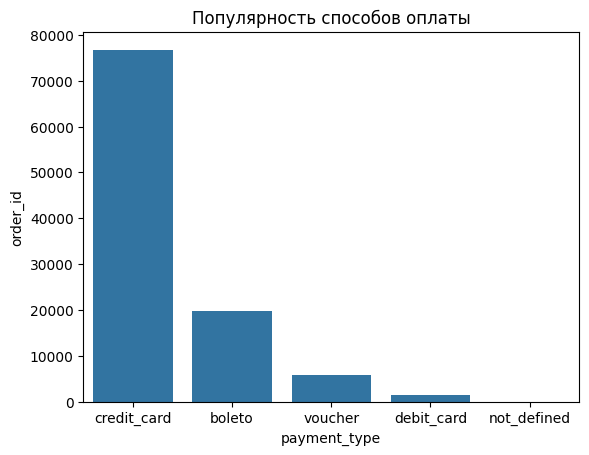

In [20]:
payments_count = order_payments.groupby("payment_type")["order_id"].count().reset_index().sort_values(by = "order_id",ascending = False)
sns.barplot(data = payments_count, x = "payment_type",y = "order_id")
plt.title("Популярность способов оплаты")
plt.show()

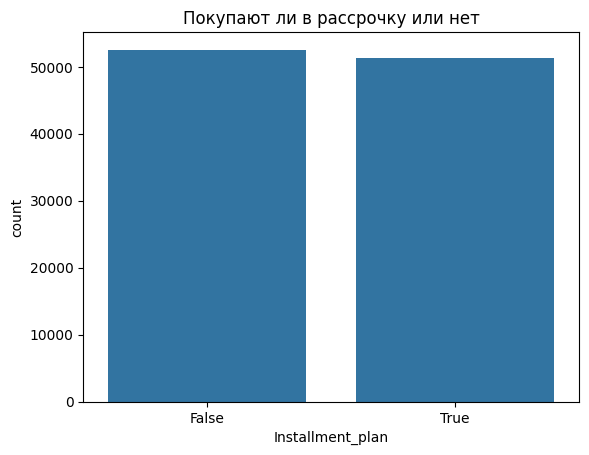

In [21]:
order_payments["Installment_plan"] = order_payments["payment_installments"].apply(lambda x: x>1)
sns.barplot(data = order_payments["Installment_plan"].value_counts())
plt.title("Покупают ли в рассрочку или нет")
plt.show()

#Сезонность

In [22]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["purchase_day"] = orders["order_purchase_timestamp"].dt.day
seasons = pd.merge(orders,order_items[["order_id","price"]], how = "left", on = "order_id").set_index("order_purchase_timestamp").sort_index().dropna()
seasons["rolling_mean_30d"] = seasons["price"].rolling(window = "30D").mean()
seasons["rolling_mean_90d"] = seasons["price"].rolling(window = "90D").mean()

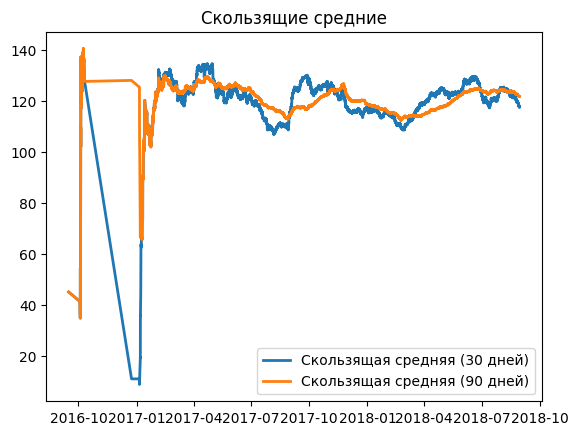

In [23]:
plt.plot(seasons.index, seasons['rolling_mean_30d'], label='Скользящая средняя (30 дней)', linewidth=2)
plt.plot(seasons.index, seasons['rolling_mean_90d'], label='Скользящая средняя (90 дней)', linewidth=2)
plt.legend()
plt.title("Скользящие средние")
plt.show()

Видно что в один из моментов времени продаж либо почти не было либо была одна - две продажи

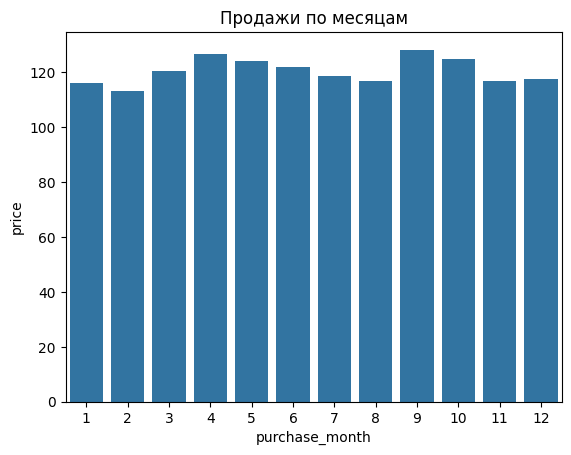

In [24]:
seasons_month_purchase = seasons.groupby("purchase_month")["price"].mean().reset_index()
sns.barplot(data = seasons_month_purchase, x = "purchase_month",y = "price")
plt.title("Продажи по месяцам")
plt.show()

Видно что по месяцам продажи почти не различаются

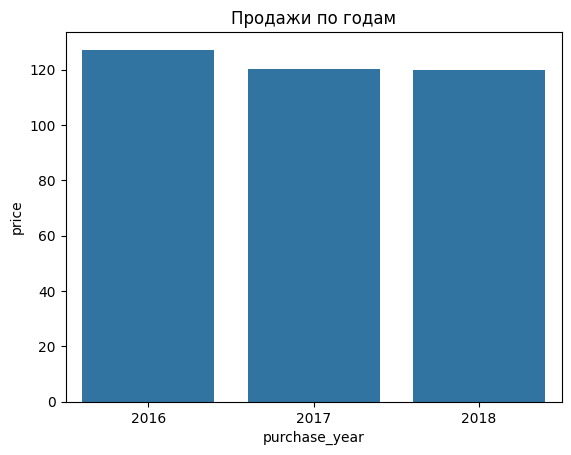

In [25]:
seasons_year_purchase = seasons.groupby("purchase_year")["price"].mean().reset_index()
sns.barplot(data = seasons_year_purchase, x = "purchase_year",y = "price")
plt.title("Продажи по годам")
plt.show()

Видем тренд на уменьшие средней цены продаж

Посмотрим как изменялось количество продаж

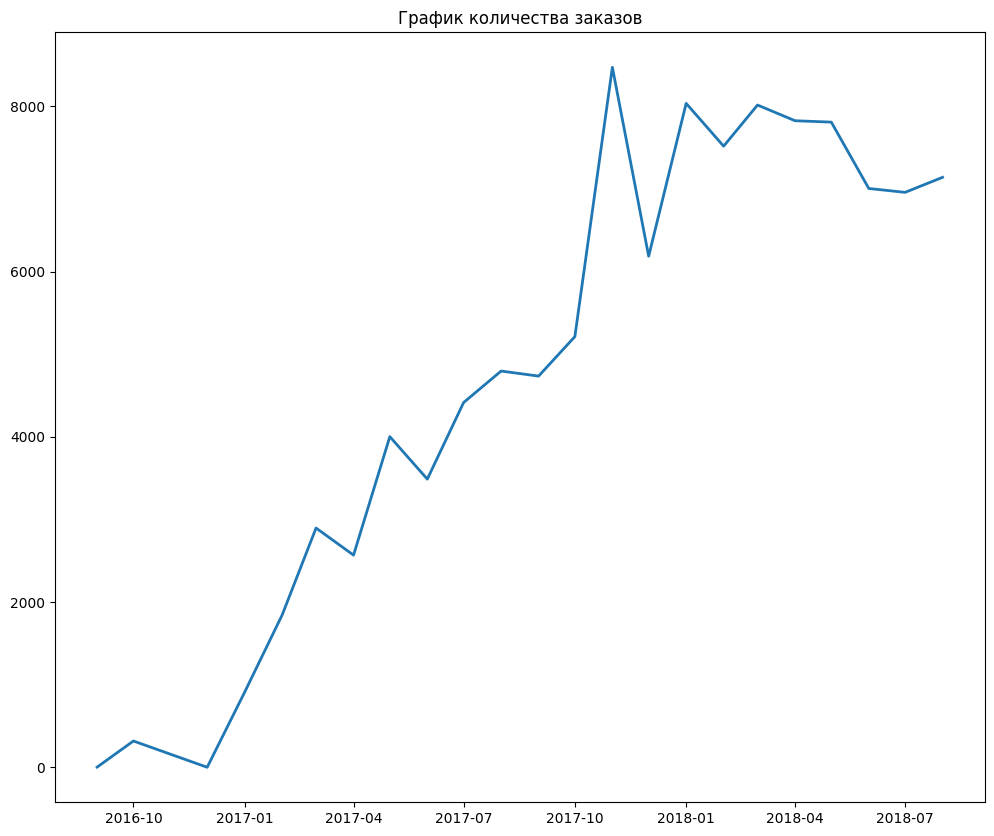

In [26]:
seasons["purchase_date_month"] = pd.to_datetime(seasons["purchase_year"].astype(str) + "-" + seasons["purchase_month"].astype(str) )
count_purchase_by_month = seasons.groupby("purchase_date_month")["order_id"].count()
fig = plt.figure(figsize = (12,10))
plt.title("График количества заказов")
plt.plot(count_purchase_by_month.index, count_purchase_by_month.values,linestyle="-", linewidth=2, markersize=4)
plt.show()

Количество заказов сильно растет, при этом странно что в 2016 году в ноябре и декабре почти не было заказов(1 заказ за два месяца), при том что в следующем месяце количество заказов утроилось по сравнении с откябрем 2016 года

In [27]:
count_purchase_by_month

,order_id
purchase_date_month,
2016-09-01,3
2016-10-01,319
2016-12-01,1
2017-01-01,911
2017-02-01,1845
2017-03-01,2897
2017-04-01,2569
2017-05-01,4003
2017-06-01,3489


#TODO RFM-анализ

RFM-анализ

In [28]:
orders["order_purchase_timestamp"].max()

Timestamp('2018-10-17 17:30:18')

In [29]:
order = pd.merge(orders,order_items[["order_id","price"]], how = "inner",on = "order_id").dropna()
rfm = order.groupby("customer_id").agg(
    frequency = ("order_id","count"),
    monetary = ("price","sum"),
    last_purchase = ("order_purchase_timestamp","max")
).reset_index()
rfm["recency"] = orders["order_purchase_timestamp"].max() - rfm["last_purchase"]
rfm["R_score"] = pd.qcut(rfm["recency"],q = 5, labels = [5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method = "first"),q = 5, labels = [1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["monetary"],q = 5, labels = [1,2,3,4,5])
rfm["RFM"] = (rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str))

In [38]:
def rfm_segment_label(rfm_code: str) -> str:
    r, f, m = int(rfm_code[0]), int(rfm_code[1]), int(rfm_code[2])
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalist"
    elif r == 5 and f <= 2:
        return "New Customers"
    elif r >= 3 and f <= 2 and m <= 2:
        return "Promising"
    elif r == 3 and f == 3 and m == 3:
        return "Need Attention"
    elif r <= 3 and f <= 2 and m <= 2:
        return "About to Sleep"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f >= 4 and m >= 4:
        return  "Lose Them"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Sleeping"
    elif r == 1 and f == 1 and m == 1:
        return "Lost"
    else:
        return "Other"
def apply_rfm_labels(df: pd.DataFrame, rfm_col: str = "RFM") -> pd.DataFrame:
    df = df.copy()
    df["RFM_Segment"] = df[rfm_col].astype(str).apply(rfm_segment_label)
    return df
rfm = apply_rfm_labels(rfm)

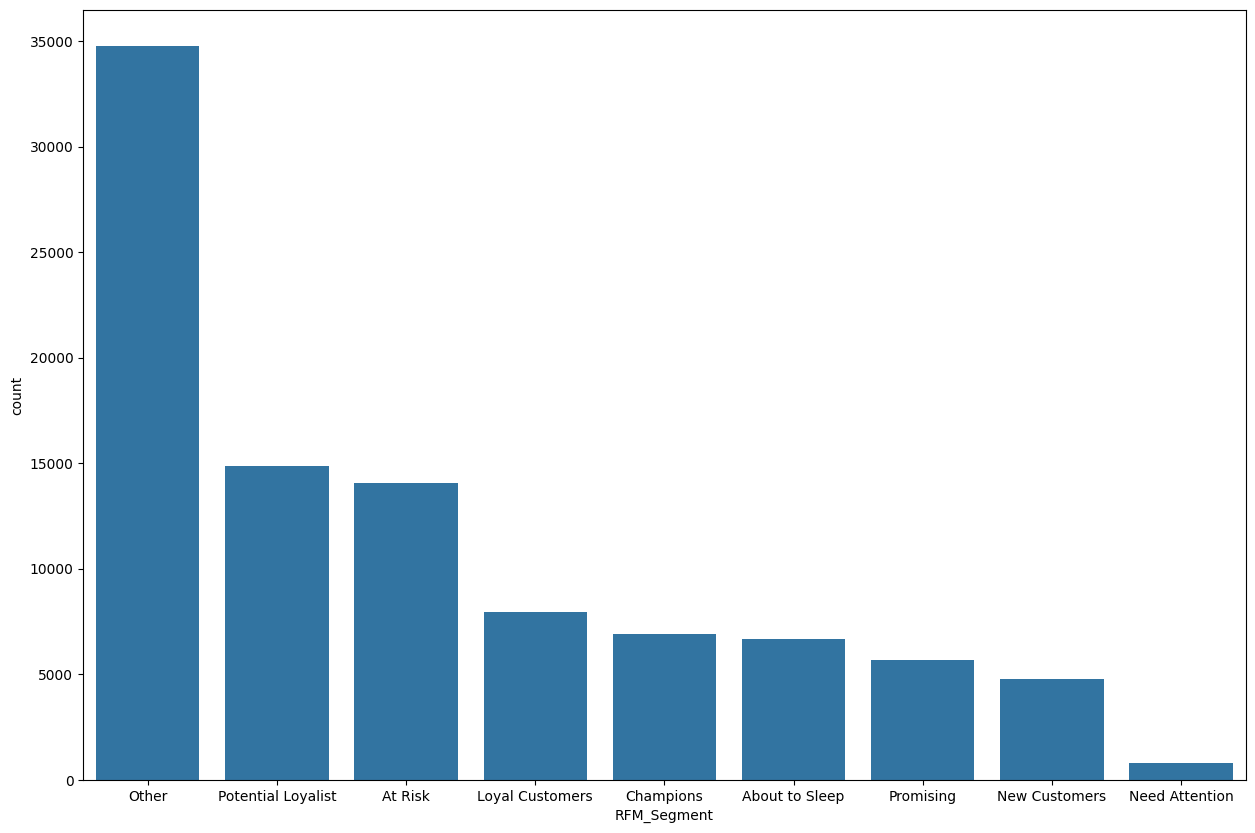

In [46]:
rfm_counts = rfm["RFM_Segment"].value_counts().reset_index()
fig = plt.figure(figsize = (15,10))
sns.barplot(data = rfm_counts, x = "RFM_Segment", y = "count")
plt.show()

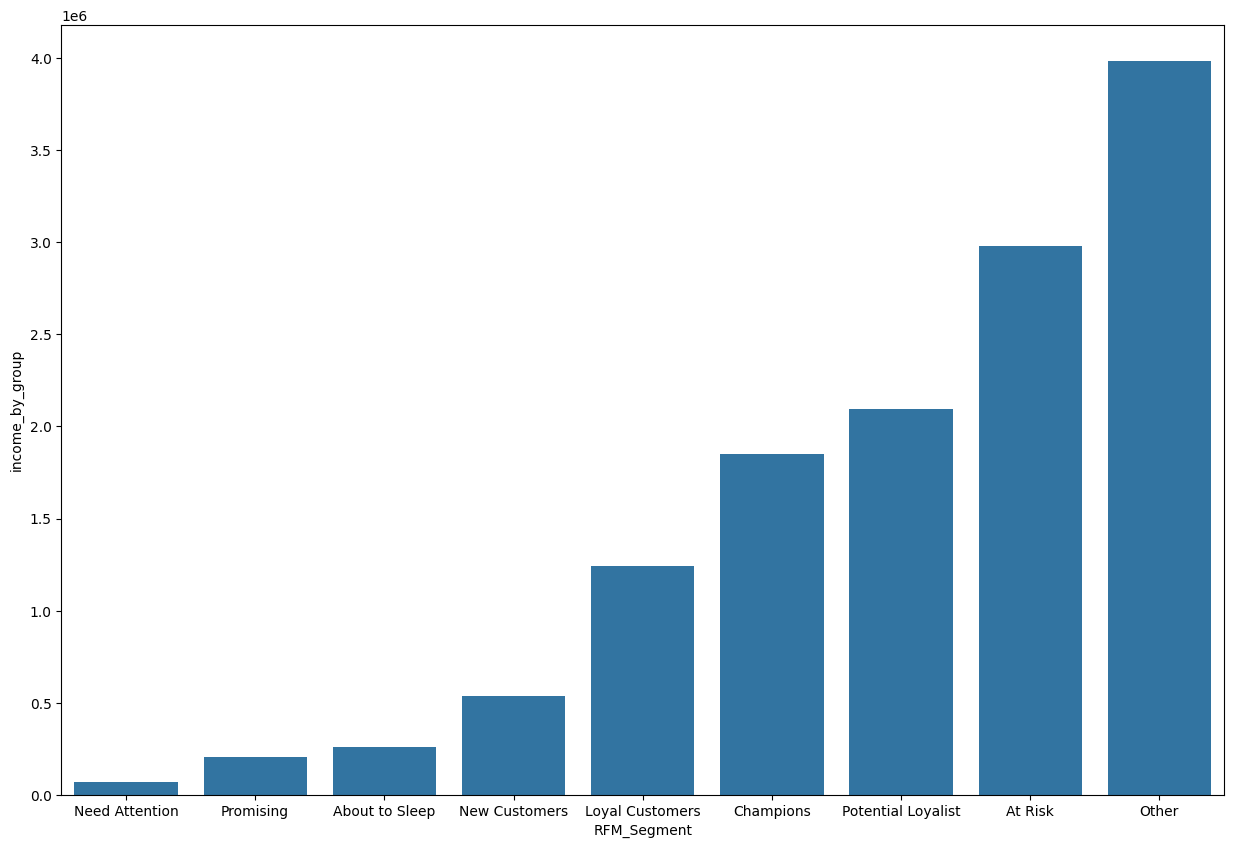

In [49]:
rfm_income = rfm.groupby("RFM_Segment")["monetary"].sum().reset_index().rename(columns = {"monetary":"income_by_group"}).sort_values(by = "income_by_group")
fig = plt.figure(figsize = (15,10))
sns.barplot(data = rfm_income, x = "RFM_Segment", y = "income_by_group")
plt.show()

Видно, что те клиенты, которые раньше покупали часто и много, приносят больше всего из выделенных групп, также основную выручку приносят клиенты, которые пришли недавно

/tmp/ipykernel_509/2070654595.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_509/2070654595.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



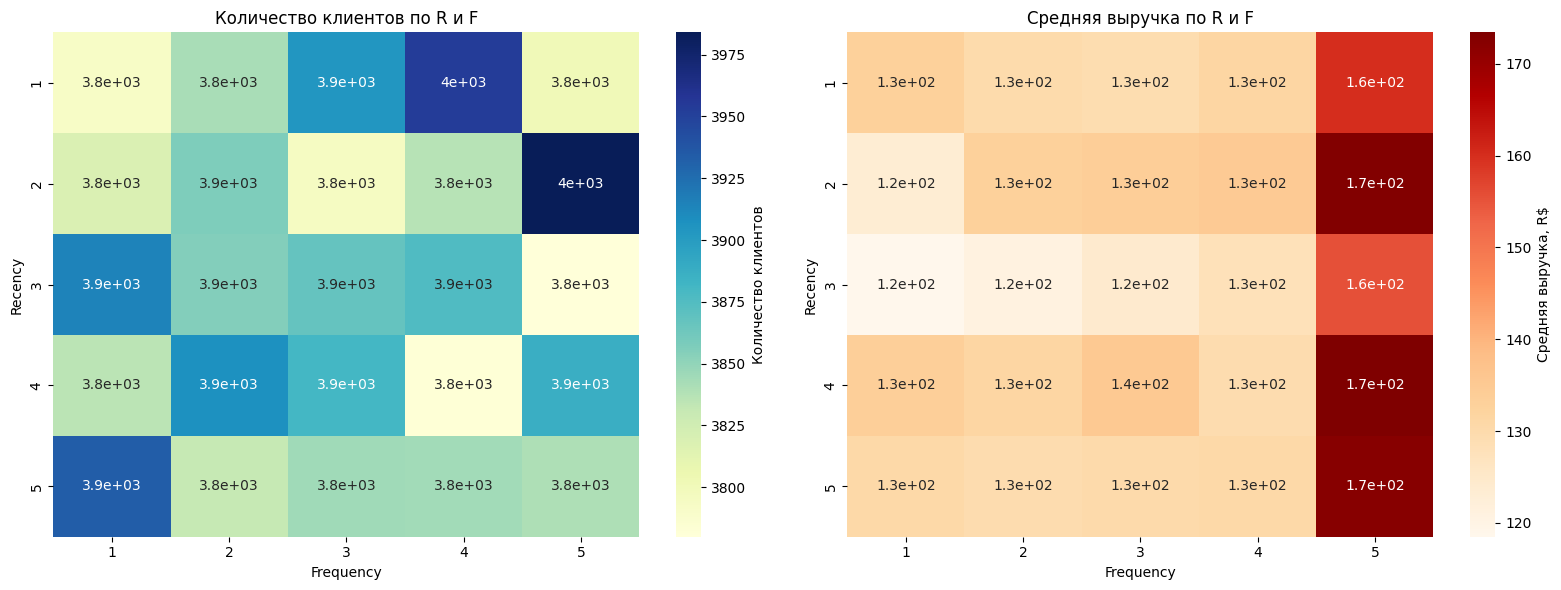

In [57]:
rf_counts = rfm.groupby(["R_score", "F_score"]).size().unstack(fill_value=0)
rf_revenue = rfm.groupby(["R_score", "F_score"])["monetary"].mean().unstack(fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(
    rf_counts,
    annot=True, cmap='YlGnBu',
    ax=axes[0], cbar_kws={"label": "Количество клиентов"}
)
axes[0].set_title("Количество клиентов по R и F")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Recency")
axes[0].invert_yaxis()
sns.heatmap(
    rf_revenue,
    annot=True, cmap="OrRd",
    ax=axes[1], cbar_kws={"label": "Средняя выручка, R$"}
)
axes[1].set_title("Средняя выручка по R и F")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Recency")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()